In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)
df = pd.read_csv("../data/val_preds_distilbert-v1-512.csv")
errors = df[~df["correct"]]
print(f"{len(errors)} errors out of {len(df)} ({len(errors)/len(df):.1%})")

1222 errors out of 9000 (13.6%)


In [2]:
pairs = (errors.groupby(["label", "pred"]).size()
               .sort_values(ascending=False).head(8))
print(pairs)

label                  pred                 
credit_report_dispute  report_misuse            147
                       debt_collection          112
debt_collection        credit_report_dispute    107
report_misuse          credit_report_dispute     91
credit_report_dispute  consumer_loans            75
debt_collection        consumer_loans            70
credit_report_dispute  cards_and_accounts        54
consumer_loans         debt_collection           52
dtype: int64


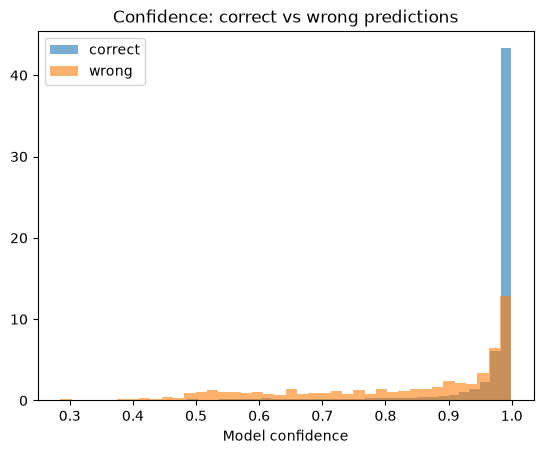

Median confidence when correct: 0.99302997
Median confidence when wrong:   0.90373675


In [3]:
plt.hist(df.loc[df["correct"], "confidence"], bins=40, alpha=0.6, label="correct", density=True)
plt.hist(errors["confidence"], bins=40, alpha=0.6, label="wrong", density=True)
plt.xlabel("Model confidence"); plt.legend()
plt.title("Confidence: correct vs wrong predictions")
plt.show()

print("Median confidence when correct:", df.loc[df["correct"], "confidence"].median())
print("Median confidence when wrong:  ", errors["confidence"].median())

In [4]:
df["n_words"] = df["text"].str.split().str.len()
df["length_bucket"] = pd.cut(df["n_words"], [0, 100, 200, 400, 10_000],
                             labels=["<100", "100-200", "200-400", "400+"])
print(df.groupby("length_bucket", observed=True)["correct"].agg(["mean", "count"]))

                   mean  count
length_bucket                 
<100           0.839683   3281
100-200        0.863050   2636
200-400        0.891477   2018
400+           0.891080   1065


In [5]:
sample = (errors.sort_values("confidence", ascending=False)
                .groupby(["label", "pred"]).head(5)
                .head(50)[["label", "pred", "confidence", "text"]])
sample["reason"] = ""
sample.to_csv("../data/error_sample.csv", index=False)
print(len(sample), "rows saved")

50 rows saved


In [7]:
tagged = pd.read_csv("../data/error_sample.csv")
print(tagged["reason"].value_counts())
print(pd.crosstab(tagged["label"] + " -> " + tagged["pred"], tagged["reason"]))

reason
label_wrong    25
ambiguous      12
model_error    12
truncated       1
Name: count, dtype: int64
reason                                       ambiguous  label_wrong  \
row_0                                                                 
cards_and_accounts -> consumer_loans                 0            1   
cards_and_accounts -> mortgage                       1            3   
consumer_loans -> cards_and_accounts                 0            3   
consumer_loans -> credit_report_dispute              1            0   
consumer_loans -> debt_collection                    0            1   
consumer_loans -> mortgage                           0            1   
credit_report_dispute -> cards_and_accounts          2            2   
credit_report_dispute -> debt_collection             1            1   
credit_report_dispute -> mortgage                    4            0   
debt_collection -> cards_and_accounts                0            5   
debt_collection -> consumer_loans          